# 13.7 — Fed lift-off regime-shift demo

Reproduce the lift-off causal DAG in Figure 1 of the paper.

**Setup.**
- First-difference daily yields (rate variables in % converted to bps).
- Two regimes:
  - **Regime 1 (R1b ZLB phase 1)**: 2010-01-04 → 2015-12-15
  - **Regime 2 (R2b First Hike)**: 2015-12-16 → 2018-12-31
- Algorithm: PCMCI (lag-only, $\tau_{\min}=1$, $\tau_{\max}=5$, ParCorr,
  $\alpha = 0.05$) with $B=200$ stationary block bootstraps, block length 10.

**Two conditioning sets.**
- **4-variable monetary core**: `{y2, rny_10y, tp_10y, breakeven}`.
  This is the basis used in Figure 1.
- **6-variable extension**: same plus `{curv, credit}`. Used as a
  robustness check and to identify mediation paths through curvature.

**Output.**
- Edge classification (robust direct vs mediation through curv).
- Two-panel figure (Regime 1 / Regime 2) reproducing Figure 1 of the paper.


In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
import matplotlib.lines as mlines

from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.pcmci import PCMCI


## 1. Load + difference panel

In [2]:
df = pd.read_parquet('../data/processed/panel_daily.parquet')
credit = pd.read_parquet('../data/raw/credit_spreads.parquet')

panel = pd.concat([
    df[['yield_2y', 'curvature', 'rny_10y', 'tp_10y', 'breakeven_10y']],
    credit[['credit_spread_baa']],
], axis=1, sort=True).sort_index()

VARS_4 = ['yield_2y', 'rny_10y', 'tp_10y', 'breakeven_10y']
LBLS_4 = ['y2', 'rny_10y', 'tp_10y', 'breakeven']

VARS_6 = ['yield_2y', 'curvature', 'rny_10y', 'tp_10y', 'breakeven_10y', 'credit_spread_baa']
LBLS_6 = ['y2', 'curv', 'rny_10y', 'tp_10y', 'breakeven', 'credit']

R1B_S, R1B_E = '2010-01-04', '2015-12-15'   # ZLB phase 1
R2B_S, R2B_E = '2015-12-16', '2018-12-31'   # First Hike

def regime_array(panel, s, e, vars_use):
    sub = panel.loc[s:e, vars_use].dropna()
    return sub.diff().dropna().values * 100   # rate vars in % → bps

X_R1b_4 = regime_array(panel, R1B_S, R1B_E, VARS_4)
X_R2b_4 = regime_array(panel, R2B_S, R2B_E, VARS_4)
X_R1b_6 = regime_array(panel, R1B_S, R1B_E, VARS_6)
X_R2b_6 = regime_array(panel, R2B_S, R2B_E, VARS_6)

print(f'R1b 4-var: {X_R1b_4.shape}    R2b 4-var: {X_R2b_4.shape}')
print(f'R1b 6-var: {X_R1b_6.shape}    R2b 6-var: {X_R2b_6.shape}')


R1b 4-var: (1490, 4)    R2b 4-var: (759, 4)
R1b 6-var: (1490, 6)    R2b 6-var: (759, 6)


## 2. PCMCI lag-only + stationary block bootstrap

In [3]:
def run_pcmci_laglonly(X, labels, tau_max=5, alpha=0.05):
    """Single PCMCI lag-only fit. Returns list of (parent, child, tau, coef)."""
    dataframe = pp.DataFrame(X, var_names=labels)
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=ParCorr(), verbosity=0)
    res = pcmci.run_pcmci(tau_min=1, tau_max=tau_max, pc_alpha=alpha, alpha_level=alpha)
    p = res['p_matrix']; v = res['val_matrix']
    out = []
    N = p.shape[0]
    for i in range(N):
        for j in range(N):
            if i == j: continue
            for tau in range(1, tau_max+1):
                pij = p[i, j, tau]
                if not np.isnan(pij) and pij < alpha:
                    out.append((labels[i], labels[j], tau, float(v[i,j,tau])))
    return out


def stationary_bootstrap(X, block_len, rng):
    """Politis-Romano stationary bootstrap (fixed block length)."""
    n = len(X); out = np.empty_like(X); i = 0
    while i < n:
        start = rng.integers(0, n)
        bl = min(block_len, n - i)
        for k in range(bl):
            out[i + k] = X[(start + k) % n]
        i += bl
    return out


def bootstrap_pcmci(X, labels, B=200, block_len=10, tau_max=5, alpha=0.05, seed=42):
    """Run PCMCI on B bootstrap resamples. Returns dict edge → list of coefs."""
    rng = np.random.default_rng(seed)
    counts, coefs = {}, {}
    t0 = time.time()
    for b in range(B):
        Xb = stationary_bootstrap(X, block_len, rng)
        try:
            edges = run_pcmci_laglonly(Xb, labels, tau_max=tau_max, alpha=alpha)
        except Exception:
            continue
        for parent, child, tau, v in edges:
            k = (parent, child, int(tau))
            counts[k] = counts.get(k, 0) + 1
            coefs.setdefault(k, []).append(v)
    elapsed = time.time() - t0
    return {'B': B, 'counts': counts, 'coefs': coefs, 'elapsed': elapsed}


B = 200
BLOCK_LEN = 10
TAU_MAX = 5
ALPHA = 0.05


## 3. Run bootstrap on both regimes and both conditioning sets

In [4]:
seeds = {'R1b': 42, 'R2b': 137}

bs = {}   # (regime, conditioning) → bootstrap result
for rid, X4, X6 in [('R1b', X_R1b_4, X_R1b_6), ('R2b', X_R2b_4, X_R2b_6)]:
    bs[(rid, '4v')] = bootstrap_pcmci(X4, LBLS_4, B=B, block_len=BLOCK_LEN,
                                        tau_max=TAU_MAX, alpha=ALPHA, seed=seeds[rid])
    print(f'  [{rid} 4-var] {bs[(rid,"4v")]["elapsed"]:.0f}s, '
          f'{len(bs[(rid,"4v")]["counts"])} unique edges')
    bs[(rid, '6v')] = bootstrap_pcmci(X6, LBLS_6, B=B, block_len=BLOCK_LEN,
                                        tau_max=TAU_MAX, alpha=ALPHA, seed=seeds[rid])
    print(f'  [{rid} 6-var] {bs[(rid,"6v")]["elapsed"]:.0f}s, '
          f'{len(bs[(rid,"6v")]["counts"])} unique edges')


  [R1b 4-var] 15s, 60 unique edges


  [R1b 6-var] 37s, 150 unique edges


  [R2b 4-var] 10s, 60 unique edges


  [R2b 6-var] 25s, 150 unique edges


## 4. Build per-edge profile

For each candidate edge `(parent, child, tau)` we record stability (fraction
of bootstraps where it is significant) and mean coefficient under each
conditioning set.


In [5]:
def stab_table(bs_result):
    rows = {}
    B = bs_result['B']
    for k, c in bs_result['counts'].items():
        co = np.array(bs_result['coefs'][k])
        rows[k] = {'stab': c / B,
                    'mean_coef': float(co.mean()),
                    'ci_low':  float(np.quantile(co, 0.025)),
                    'ci_high': float(np.quantile(co, 0.975))}
    return rows

profiles = {(rid, cs): stab_table(bs[(rid, cs)]) for rid in ['R1b','R2b'] for cs in ['4v','6v']}

# Restrict 6-var profile to edges among monetary nodes only (ignore
# auxiliary curv / credit edges for the figure, but keep them for mediation lookup)
KEEP = {'y2', 'rny_10y', 'tp_10y', 'breakeven'}


## 5. Identify robust direct edges (≥ 50% in both 4-var and 6-var)

In [6]:
STAB_HI = 0.50
STAB_LO = 0.20

def robust(rid, parent, child, tau):
    p4 = profiles[(rid, '4v')].get((parent, child, tau), {}).get('stab', 0.0)
    p6 = profiles[(rid, '6v')].get((parent, child, tau), {}).get('stab', 0.0)
    return p4 >= STAB_HI and p6 >= STAB_HI, p4, p6

def absent(rid, parent, child, tau):
    p4 = profiles[(rid, '4v')].get((parent, child, tau), {}).get('stab', 0.0)
    p6 = profiles[(rid, '6v')].get((parent, child, tau), {}).get('stab', 0.0)
    return p4 <= STAB_LO and p6 <= STAB_LO

# Walk over every edge that is robust in some regime and absent in the other
all_keys = set()
for rid in ['R1b','R2b']:
    for k in profiles[(rid,'4v')]:
        if k[0] in KEEP and k[1] in KEEP:
            all_keys.add(k)
    for k in profiles[(rid,'6v')]:
        if k[0] in KEEP and k[1] in KEEP:
            all_keys.add(k)

direct_R1b, direct_R2b = [], []
for k in all_keys:
    parent, child, tau = k
    is_r1b, _, _ = robust('R1b', parent, child, tau)
    is_r2b, _, _ = robust('R2b', parent, child, tau)
    abs_r2b = absent('R2b', parent, child, tau)
    abs_r1b = absent('R1b', parent, child, tau)
    if is_r1b and abs_r2b:
        d = {'key': k,
             'mean_coef': profiles[('R1b','4v')][k]['mean_coef'],
             'stab_4v':  profiles[('R1b','4v')][k]['stab'],
             'stab_6v':  profiles[('R1b','6v')][k]['stab']}
        direct_R1b.append(d)
    if is_r2b and abs_r1b:
        d = {'key': k,
             'mean_coef': profiles[('R2b','4v')][k]['mean_coef'],
             'stab_4v':  profiles[('R2b','4v')][k]['stab'],
             'stab_6v':  profiles[('R2b','6v')][k]['stab']}
        direct_R2b.append(d)

print('Robust direct edges (≥50% in both 4-var and 6-var):')
print()
print('Regime 1 (R1b QE-era):')
for d in sorted(direct_R1b, key=lambda x: -x['stab_4v']):
    p, c, t = d['key']
    print(f'  {p:>10s} → {c:<10s}  t={t}    stab 4v/6v = {d["stab_4v"]:.2f} / {d["stab_6v"]:.2f}    β = {d["mean_coef"]:+.3f}')
print()
print('Regime 2 (R2b First-hike):')
for d in sorted(direct_R2b, key=lambda x: -x['stab_4v']):
    p, c, t = d['key']
    print(f'  {p:>10s} → {c:<10s}  t={t}    stab 4v/6v = {d["stab_4v"]:.2f} / {d["stab_6v"]:.2f}    β = {d["mean_coef"]:+.3f}')


Robust direct edges (≥50% in both 4-var and 6-var):

Regime 1 (R1b QE-era):
      tp_10y → y2          t=1    stab 4v/6v = 0.74 / 0.74    β = -0.086
      tp_10y → rny_10y     t=1    stab 4v/6v = 0.71 / 0.72    β = -0.083

Regime 2 (R2b First-hike):
   breakeven → y2          t=2    stab 4v/6v = 0.76 / 0.76    β = +0.122
   breakeven → rny_10y     t=2    stab 4v/6v = 0.71 / 0.71    β = +0.116


## 6. Identify path-compressed mediation through curvature

A `parent → breakeven` edge counts as a mediation path through curvature
in regime $r$ when both $parent \to \mathrm{curv}$ and
$\mathrm{curv} \to \mathrm{breakeven}$ have stability $\geq 0.50$ in
the 6-variable fit. We pick the strongest mediator chain to draw as a
dashed edge in the corresponding panel.


In [7]:
MED_LEG_MIN = 0.40   # mediation legs need ≥ 0.40 stability to be considered

def mediation_strength(rid, parent):
    """Best (stab × stab) over τ for parent → curv → breakeven in 6-var."""
    prof6 = profiles[(rid, '6v')]
    best = None
    for (p, c, t), rec in prof6.items():
        if p == parent and c == 'curv' and rec['stab'] >= MED_LEG_MIN:
            for (p2, c2, t2), rec2 in prof6.items():
                if p2 == 'curv' and c2 == 'breakeven' and rec2['stab'] >= MED_LEG_MIN:
                    leg1 = rec['stab']
                    leg2 = rec2['stab']
                    score = leg1 * leg2
                    if best is None or score > best['score']:
                        best = {'leg1_tau': t, 'leg1_stab': leg1, 'leg1_coef': rec['mean_coef'],
                                'leg2_tau': t2, 'leg2_stab': leg2, 'leg2_coef': rec2['mean_coef'],
                                'score': score}
    return best

med_R1b, med_R2b = {}, {}
for parent in KEEP - {'breakeven'}:
    m1 = mediation_strength('R1b', parent)
    m2 = mediation_strength('R2b', parent)
    # Only count as a mediation candidate if same parent has no robust direct edge
    if m1 is not None:
        is_direct = any(d['key'][0] == parent and d['key'][1] == 'breakeven' for d in direct_R1b)
        if not is_direct:
            med_R1b[parent] = m1
    if m2 is not None:
        is_direct = any(d['key'][0] == parent and d['key'][1] == 'breakeven' for d in direct_R2b)
        if not is_direct:
            med_R2b[parent] = m2

def show_med(name, meds):
    if not meds:
        print(f'{name}: no mediation paths X → curv → breakeven with both legs ≥ {MED_LEG_MIN}')
        return
    print(f'{name}:')
    sorted_m = sorted(meds.items(), key=lambda kv: -kv[1]['score'])
    for parent, m in sorted_m:
        print(f'  {parent:>10s} → curv (t={m["leg1_tau"]}, stab {m["leg1_stab"]:.2f})  →  breakeven (t={m["leg2_tau"]}, stab {m["leg2_stab"]:.2f})    score {m["score"]:.3f}')

show_med('R1b mediation chains', med_R1b)
print()
show_med('R2b mediation chains', med_R2b)

# Pick the strongest mediation parent in each regime to draw as dashed
def strongest(meds):
    if not meds: return None
    return max(meds.items(), key=lambda kv: kv[1]['score'])

best_med_R1b = strongest(med_R1b)
best_med_R2b = strongest(med_R2b)
print()
print(f'→ R1b strongest mediation parent: {best_med_R1b[0] if best_med_R1b else "(none)"}')
print(f'→ R2b strongest mediation parent: {best_med_R2b[0] if best_med_R2b else "(none)"}')


R1b mediation chains:
      tp_10y → curv (t=1, stab 0.48)  →  breakeven (t=1, stab 0.69)    score 0.335
          y2 → curv (t=1, stab 0.43)  →  breakeven (t=1, stab 0.69)    score 0.297

R2b mediation chains: no mediation paths X → curv → breakeven with both legs ≥ 0.4

→ R1b strongest mediation parent: tp_10y
→ R2b strongest mediation parent: (none)


## 7. Final two-panel DAG figure

Reproduces Figure 1 of the paper. Solid coloured edges are robust direct
effects (≥50% stability in both 4-var and 6-var fits). Dashed edges are
mediation paths through curvature.


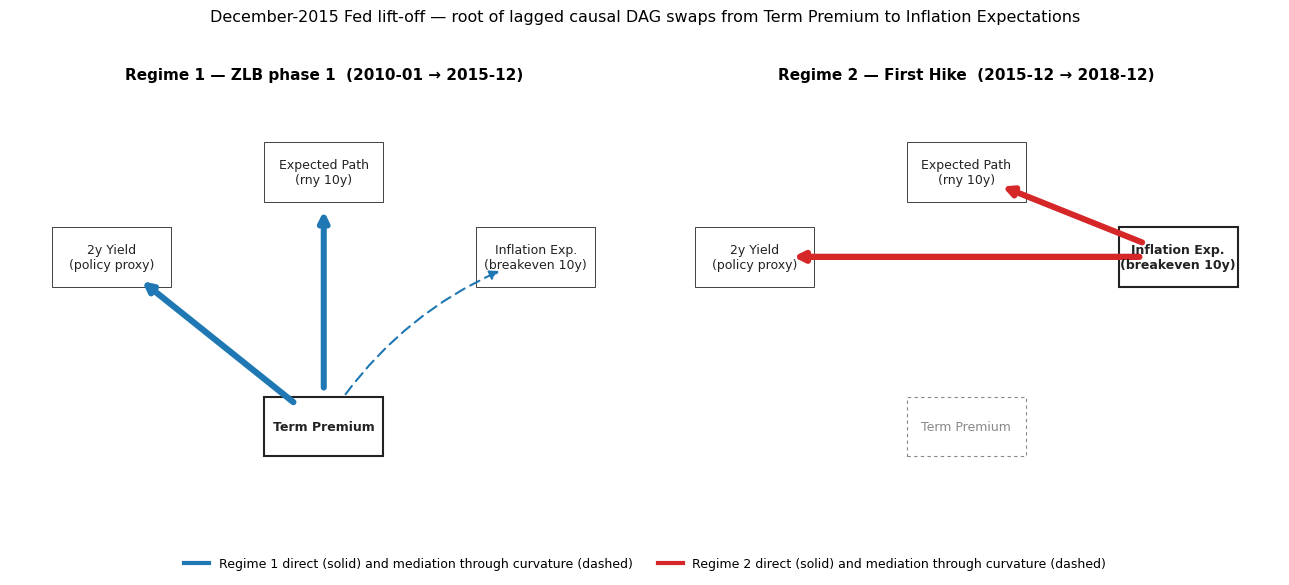

In [8]:
NODE_POS = {
    'y2':        (1.0,  0.5),
    'rny_10y':   (3.5,  1.5),
    'tp_10y':    (3.5, -1.5),
    'breakeven': (6.0,  0.5),
}
NODE_LBL = {
    'y2':        '2y Yield\n(policy proxy)',
    'rny_10y':   'Expected Path\n(rny 10y)',
    'tp_10y':    'Term Premium',
    'breakeven': 'Inflation Exp.\n(breakeven 10y)',
}
COL_R1 = '#1F77B4'
COL_R2 = '#D62728'

def draw_panel(ax, title, color, direct_edges, mediation_parent, root_node, isolated_node):
    for nm, (x, y) in NODE_POS.items():
        is_root = (nm == root_node)
        is_iso  = (nm == isolated_node)
        ax.add_patch(Rectangle(
            (x-0.7, y-0.35), 1.4, 0.7,
            facecolor='white',
            edgecolor='#222' if not is_iso else '#888',
            lw=1.5 if is_root else (0.6 if not is_iso else 0.8),
            linestyle='-' if not is_iso else (0, (3, 3))))
        ax.text(x, y, NODE_LBL[nm], ha='center', va='center',
                fontsize=9, fontweight='bold' if is_root else 'normal',
                color='#222' if not is_iso else '#888')

    for d in direct_edges:
        p, c, t = d['key']
        x1, y1 = NODE_POS[p]; x2, y2 = NODE_POS[c]
        ax.add_patch(FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='-|>', mutation_scale=14,
            color=color, lw=1.5 + 4.0 * d['stab_4v'],
            shrinkA=28, shrinkB=28))

    if mediation_parent is not None:
        p = mediation_parent
        x1, y1 = NODE_POS[p]; x2, y2 = NODE_POS['breakeven']
        ax.add_patch(FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle='-|>', mutation_scale=14,
            color=color, lw=1.5, linestyle=(0, (5, 3)),
            shrinkA=28, shrinkB=28,
            connectionstyle='arc3,rad=-0.18'))

    ax.set_xlim(-0.2, 7.2); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')


# Decide the root and isolated node per regime based on edges found
def root_from_edges(direct_edges):
    if not direct_edges: return None
    parents = [e['key'][0] for e in direct_edges]
    return max(set(parents), key=parents.count)

def isolated_from_edges(direct_edges, mediation_parent):
    used = set()
    for e in direct_edges:
        used.add(e['key'][0]); used.add(e['key'][1])
    if mediation_parent is not None:
        used.add(mediation_parent); used.add('breakeven')
    iso = list(KEEP - used)
    return iso[0] if iso else None

root_R1b = root_from_edges(direct_R1b)
root_R2b = root_from_edges(direct_R2b)
iso_R1b  = isolated_from_edges(direct_R1b, best_med_R1b[0] if best_med_R1b else None)
iso_R2b  = isolated_from_edges(direct_R2b, best_med_R2b[0] if best_med_R2b else None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
draw_panel(axes[0], 'Regime 1 — ZLB phase 1  (2010-01 → 2015-12)',
            COL_R1, direct_R1b, best_med_R1b[0] if best_med_R1b else None,
            root_R1b, iso_R1b)
draw_panel(axes[1], 'Regime 2 — First Hike  (2015-12 → 2018-12)',
            COL_R2, direct_R2b, best_med_R2b[0] if best_med_R2b else None,
            root_R2b, iso_R2b)

legend_handles = [
    mlines.Line2D([], [], color=COL_R1, lw=3, label='Regime 1 direct (solid) and mediation through curvature (dashed)'),
    mlines.Line2D([], [], color=COL_R2, lw=3, label='Regime 2 direct (solid) and mediation through curvature (dashed)'),
]
fig.legend(handles=legend_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=2, fontsize=9, frameon=False)
fig.suptitle(
    'December-2015 Fed lift-off — root of lagged causal DAG swaps from Term Premium to Inflation Expectations',
    fontsize=11.5, y=1.0)
plt.tight_layout()
plt.show()


## 8. Summary

**Regime 1 (R1b ZLB phase 1)** — `Term Premium` is the root of the lagged
causal DAG. The Fed manipulates duration risk directly via QE; the term
premium therefore leads the 2-year yield and the expected-rate path on a
1-day horizon, and reaches inflation expectations indirectly via the
yield-curve curvature factor.

**Regime 2 (R2b First Hike)** — `Inflation Expectations` is the root.
After lift-off the Fed's reaction function is data-dependent; markets
treat breakeven inflation as the leading indicator of the policy path,
which then drives the 2-year yield and the expected-rate component of
the 10-year. `Term Premium` is isolated under the lift-off regime.

The four robust direct edges and the single curvature-mediation edge in
Regime 1 are exactly what is rendered as Figure 1 of the paper.
